In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("week1_AI4I2020.zip")

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,...,Air temperature [K]_RollingStd,Process temperature [K]_RollingStd,Rotational speed [rpm]_RollingStd,Torque [Nm]_RollingStd,Tool wear [min]_RollingStd,Air temperature [K]_RollingVar,Process temperature [K]_RollingVar,Rotational speed [rpm]_RollingVar,Torque [Nm]_RollingVar,Tool wear [min]_RollingVar
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,...,0.054772,0.083666,62.970628,4.22315,3.49285,0.003,0.007,3965.3,17.835,12.2
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,...,0.054772,0.083666,62.970628,4.22315,3.49285,0.003,0.007,3965.3,17.835,12.2
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,...,0.054772,0.083666,62.970628,4.22315,3.49285,0.003,0.007,3965.3,17.835,12.2
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,...,0.054772,0.083666,62.970628,4.22315,3.49285,0.003,0.007,3965.3,17.835,12.2
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,...,0.054772,0.083666,62.970628,4.22315,3.49285,0.003,0.007,3965.3,17.835,12.2


In [ ]:
print("Shape:", df.shape)
df.info()

Shape: (10000, 27)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 27 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Type                                 10000 non-null  int64  
 1   Air temperature [K]                  10000 non-null  float64
 2   Process temperature [K]              10000 non-null  float64
 3   Rotational speed [rpm]               10000 non-null  int64  
 4   Torque [Nm]                          10000 non-null  float64
 5   Tool wear [min]                      10000 non-null  int64  
 6   Machine failure                      10000 non-null  int64  
 7   TWF                                  10000 non-null  int64  
 8   HDF                                  10000 non-null  int64  
 9   PWF                                  10000 non-null  int64  
 10  OSF                                  10000 non-null  int64  
 11  RNF       

In [ ]:
np.random.seed(42)

df["Ambient Temperature"] = np.random.normal(
    loc=25,
    scale=3,
    size=len(df)
)

In [ ]:
factory_load = ["Low", "Medium", "High"]

df["Factory Load"] = np.random.choice(
    factory_load,
    size=len(df),
    p=[0.3,0.5,0.2]
)

In [ ]:
load_map = {
    "Low":0,
    "Medium":1,
    "High":2
}

df["Factory Load"] = df["Factory Load"].map(load_map)

In [ ]:
df["Temperature Difference"] = (

df["Process temperature [K]"]

-

df["Air temperature [K]"]

)

In [ ]:
df["Torque_per_ToolWear"] = (

df["Torque [Nm]"]

/

(df["Tool wear [min]"]+1)

)

In [ ]:
df["Speed_Torque"] = (

df["Rotational speed [rpm]"]

*

df["Torque [Nm]"]

)

In [ ]:
df["Ambient_Impact"] = (

df["Ambient Temperature"]

*

df["Process temperature [K]"]

)

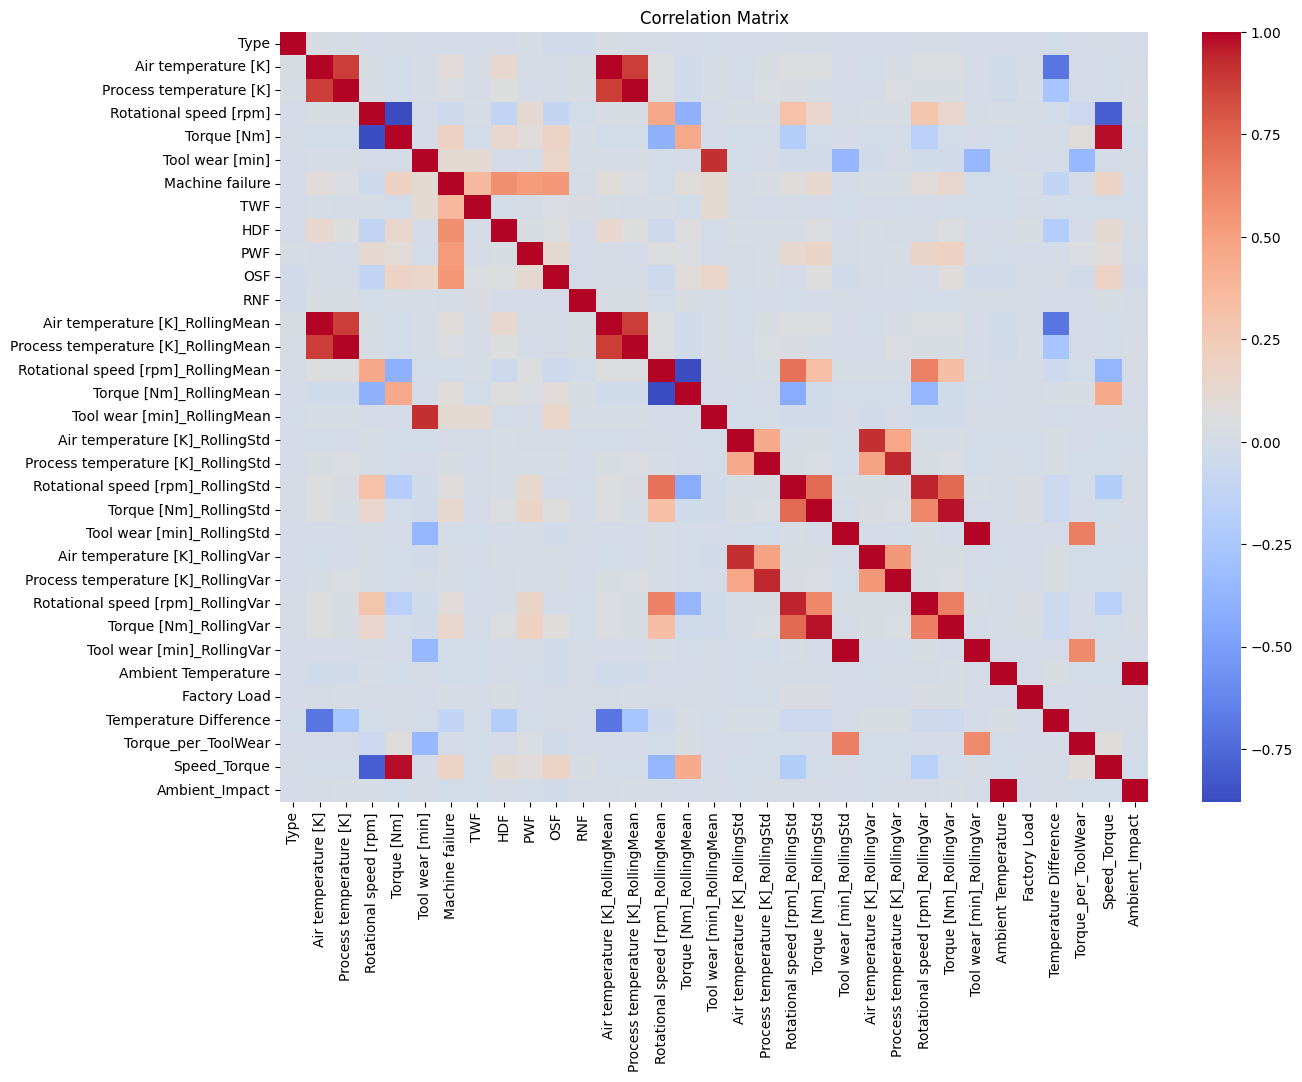

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(

df.corr(numeric_only=True),

annot=False,

cmap="coolwarm"

)

plt.title("Correlation Matrix")

plt.show()

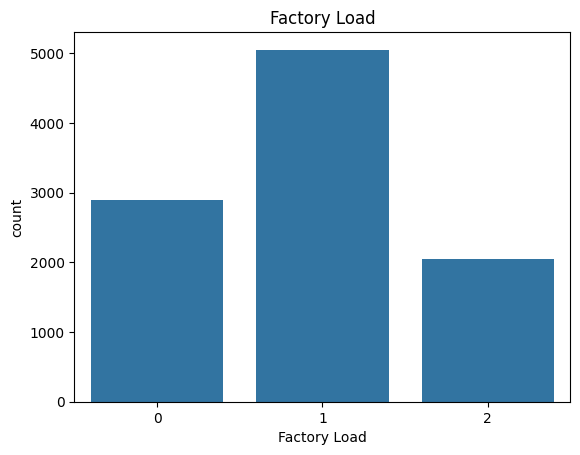

In [ ]:
sns.countplot(
    x=df["Factory Load"]
)

plt.title("Factory Load")

plt.show()

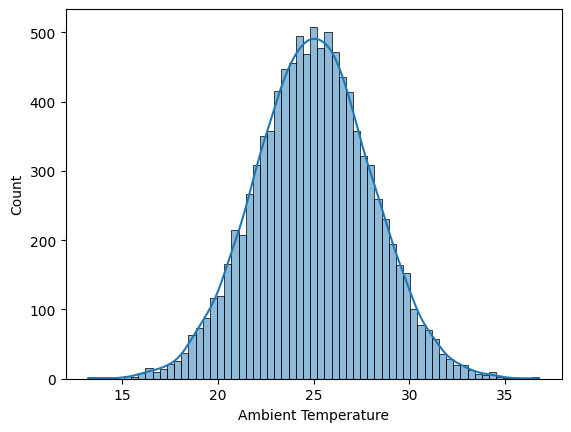

In [ ]:
sns.histplot(

df["Ambient Temperature"],

kde=True

)

plt.show()

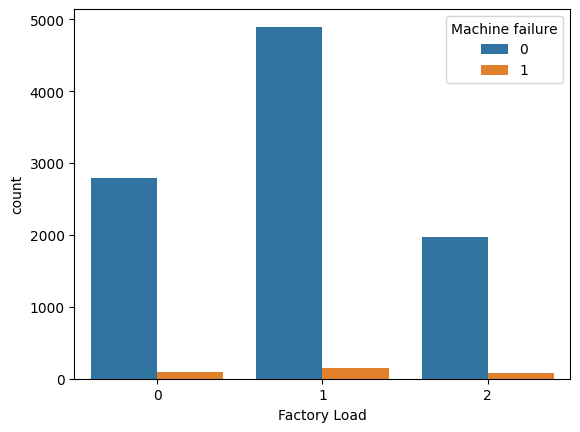

In [ ]:
sns.countplot(

data=df,

x="Factory Load",

hue="Machine failure"

)

plt.show()

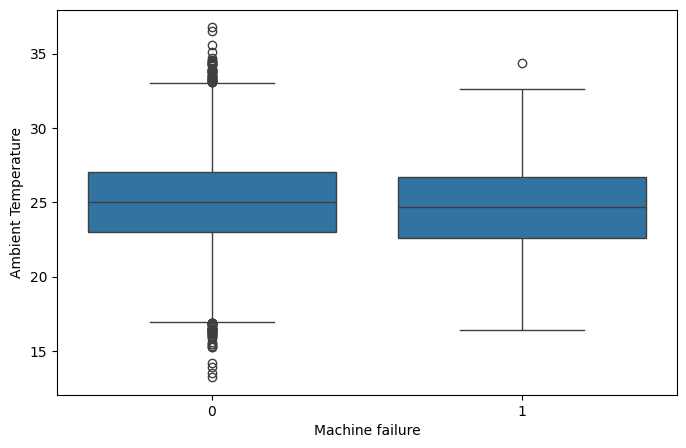

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(

data=df,

x="Machine failure",

y="Ambient Temperature"

)

plt.show()

In [ ]:
print(df.columns)

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF',
       'Air temperature [K]_RollingMean',
       'Process temperature [K]_RollingMean',
       'Rotational speed [rpm]_RollingMean', 'Torque [Nm]_RollingMean',
       'Tool wear [min]_RollingMean', 'Air temperature [K]_RollingStd',
       'Process temperature [K]_RollingStd',
       'Rotational speed [rpm]_RollingStd', 'Torque [Nm]_RollingStd',
       'Tool wear [min]_RollingStd', 'Air temperature [K]_RollingVar',
       'Process temperature [K]_RollingVar',
       'Rotational speed [rpm]_RollingVar', 'Torque [Nm]_RollingVar',
       'Tool wear [min]_RollingVar', 'Ambient Temperature', 'Factory Load',
       'Temperature Difference', 'Torque_per_ToolWear', 'Speed_Torque',
       'Ambient_Impact'],
      dtype='object')


In [ ]:
df.to_csv("week2_AI4I2020.zip",index=False)

print("Week 2 Completed Successfully")

Week 2 Completed Successfully
